# 01 — Data Exploration
Explore the dataset: class distribution, sample images, and image properties.

In [11]:
import os
import kagglehub
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

# ── 1. Download dataset ──────────────────────────────────────────
path = kagglehub.dataset_download("manuelhettich/acne04")
DATA_DIR = '../data/raw/acne_1024'
shutil.copytree(path, DATA_DIR, dirs_exist_ok=True)


# Class configuration
CLASS_FOLDERS = ['acne0_1024', 'acne1_1024', 'acne2_1024', 'acne3_1024']
CLASS_LABELS  = ['clear', 'mild', 'moderate', 'severe']
COLORS        = ['#9ccfd8', '#f6c177', '#e07b7b', '#c4a7e7']

print('Class mapping:')
for folder, label in zip(CLASS_FOLDERS, CLASS_LABELS):
    print(f'  {folder} → {label}')

Class mapping:
  acne0_1024 → clear
  acne1_1024 → mild
  acne2_1024 → moderate
  acne3_1024 → severe


## 1. Class Distribution

  clear: 483 images
  mild: 623 images
  moderate: 175 images
  severe: 96 images
  Total: 1377 images


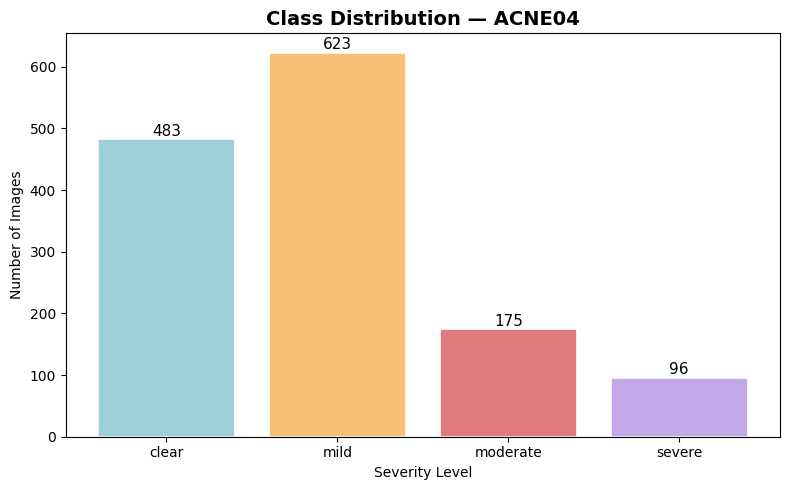

Note: imbalanced dataset — will be handled with class weights and augmentation


In [12]:
class_counts = {}
for folder, label in zip(CLASS_FOLDERS, CLASS_LABELS):
    folder_path = os.path.join(DATA_DIR, folder)
    images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    class_counts[label] = len(images)
    print(f'  {label}: {len(images)} images')
print(f'  Total: {sum(class_counts.values())} images')

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(class_counts.keys(), class_counts.values(), color=COLORS, edgecolor='white', linewidth=1.2)
ax.set_title('Class Distribution — ACNE04', fontsize=14, fontweight='bold')
ax.set_xlabel('Severity Level')
ax.set_ylabel('Number of Images')
for bar, count in zip(bars, class_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count), ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('../plots/class_distribution.png', dpi=150)
plt.show()
print('Note: imbalanced dataset — will be handled with class weights and augmentation')

## 2. Sample Images per Class

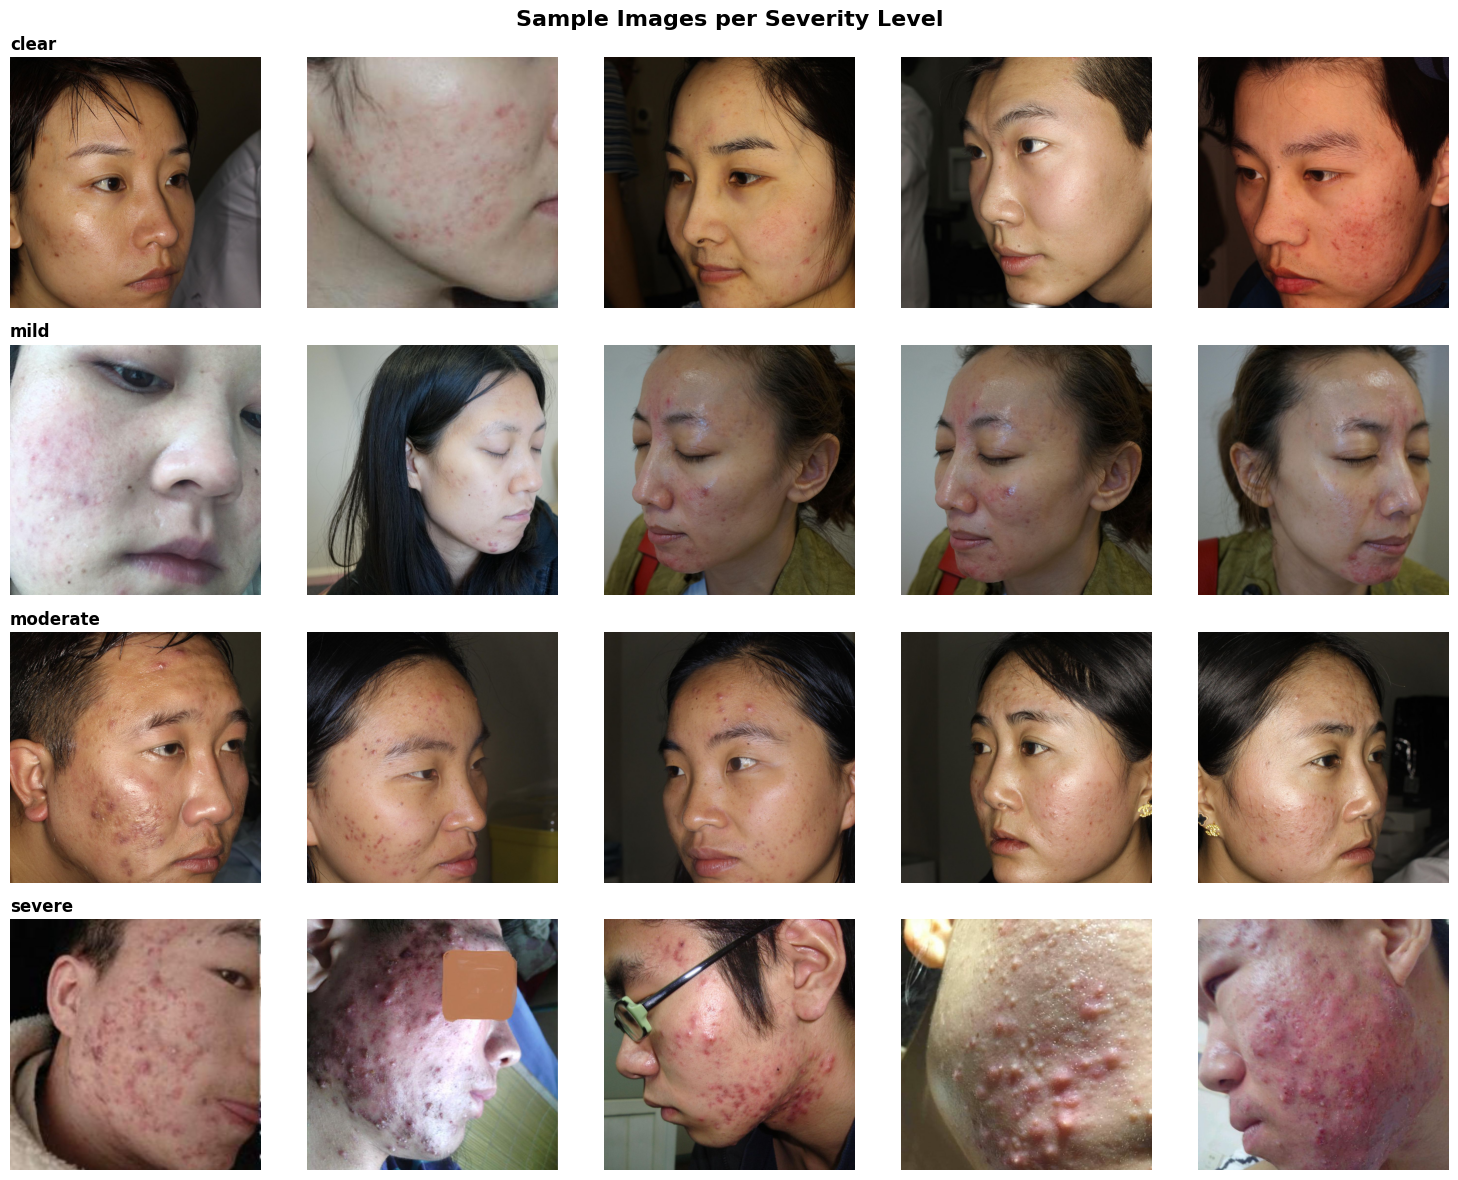

In [13]:
fig, axes = plt.subplots(len(CLASS_FOLDERS), 5, figsize=(15, 3 * len(CLASS_FOLDERS)))
fig.suptitle('Sample Images per Severity Level', fontsize=16, fontweight='bold')

for i, (folder, label) in enumerate(zip(CLASS_FOLDERS, CLASS_LABELS)):
    folder_path = os.path.join(DATA_DIR, folder)
    images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:5]
    for j, img_name in enumerate(images):
        img = Image.open(os.path.join(folder_path, img_name)).convert('RGB')
        axes[i][j].imshow(img)
        axes[i][j].axis('off')
        if j == 0:
            axes[i][j].set_title(label, fontsize=12, fontweight='bold', loc='left')

plt.tight_layout()
plt.savefig('../plots/sample_images.png', dpi=150)
plt.show()

## 3. Image Size Distribution

Width  — min: 1024, max: 1024, median: 1024
Height — min: 1024, max: 1024, median: 1024


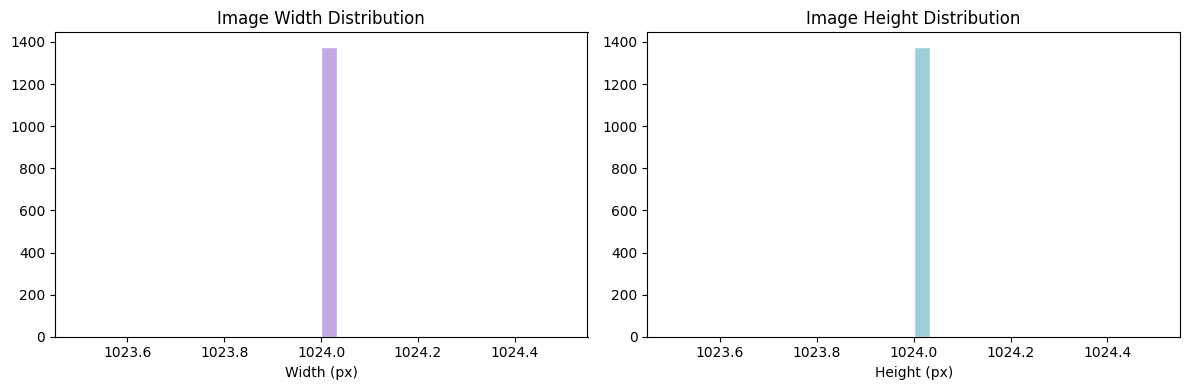

In [14]:
widths, heights = [], []
for folder in CLASS_FOLDERS:
    folder_path = os.path.join(DATA_DIR, folder)
    for img_name in os.listdir(folder_path):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            try:
                img = Image.open(os.path.join(folder_path, img_name))
                w, h = img.size
                widths.append(w)
                heights.append(h)
            except Exception:
                pass

print(f'Width  — min: {min(widths)}, max: {max(widths)}, median: {int(np.median(widths))}')
print(f'Height — min: {min(heights)}, max: {max(heights)}, median: {int(np.median(heights))}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=30, color='#c4a7e7', edgecolor='white')
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('Width (px)')
axes[1].hist(heights, bins=30, color='#9ccfd8', edgecolor='white')
axes[1].set_title('Image Height Distribution')
axes[1].set_xlabel('Height (px)')
plt.tight_layout()
plt.savefig('../plots/image_sizes.png', dpi=150)
plt.show()